<a href="https://colab.research.google.com/github/hbisgin/DeepLearning/blob/main/DL_14_WeightSharing_Q.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import  nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms
import urllib.request
from matplotlib.pyplot import imshow
from torch.utils.data import  *
from tqdm import tqdm
import time
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
import seaborn as sns






In [2]:
mnist_data_train = torchvision.datasets.MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
mnist_data_test = torchvision.datasets.MNIST("./data", train=False, download=True, transform=transforms.ToTensor())
x_example, y_example = mnist_data_train[0]
print(x_example.shape)

torch.Size([1, 28, 28])


In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

B = 32
mnist_train_loader = DataLoader(mnist_data_train, batch_size=B, shuffle=True)
mnist_test_loader = DataLoader(mnist_data_test, batch_size=B)

In [4]:
print(device)

cuda


In [5]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28*28 #28 * 28 images
#How many channels are in the input?
C = 1
#How many classes are there?
classes = 10
#How many filters should we use. The network learns 16 different filters, each trying to detect a different pattern (edges, blobs, strokes, etc.).
filters = 16
#how large should our filters be?
K = 3
n = 256
#for comparison, lets define a linear model of similar complexity
model_linear = nn.Sequential(
  nn.Flatten(), #(B, C, W, H) -> (B, C*W*H) = (B,D)
  nn.Linear(D, 256),
  nn.Tanh(),
  nn.Linear(256, classes),
)

In [6]:
#How many values are in the input? We use this to help determine the size of subsequent layers
D = 28*28 #28 * 28 images
#Hidden layer size
n = 256
#How many channels are in the input?
C = 1
#How many classes are there?
classes = 10

#Create our regular model
model_regular = nn.Sequential(
  nn.Flatten(),
  nn.Linear(D, n),
  nn.Tanh(),
  nn.Linear(n, n),
  nn.Tanh(),
  nn.Linear(n, n),
  nn.Tanh(),
  nn.Linear(n, classes),
)

In [7]:
def run_epoch(model, optimizer, data_loader, loss_func, device, results, score_funcs, prefix="", desc=None):
    running_loss = []
    y_true = []
    y_pred = []
    start = time.time()
    for inputs, labels in tqdm(data_loader, desc=desc, leave=False):
        #Move the batch to the device we are using.
        inputs = inputs.to(device)
        labels = labels.to(device)

        y_hat = model(inputs) #this just computed f_Θ(x(i))
        # Compute loss.
        loss = loss_func(y_hat, labels)

        if model.training: #check the flag
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        #Now we are just grabbing some information we would like to have
        running_loss.append(loss.item())

        if len(score_funcs) > 0 and isinstance(labels, torch.Tensor):
            #moving labels & predictions back to CPU for computing / storing predictions
            labels = labels.detach().cpu().numpy() # we have this info in the slides. Please remember why I am detaching
            y_hat = y_hat.detach().cpu().numpy()
            #add to predictions so far
            y_true.extend(labels.tolist())
            y_pred.extend(y_hat.tolist())
    #end training epoch
    end = time.time()

    y_pred = np.asarray(y_pred)
    if len(y_pred.shape) == 2 and y_pred.shape[1] > 1: #We have a classification problem, convert to labels
        y_pred = np.argmax(y_pred, axis=1)
    #Else, we assume we are working on a regression problem

    results[prefix + " loss"].append( np.mean(running_loss) )
    for name, score_func in score_funcs.items():
        try:
            results[prefix + " " + name].append( score_func(y_true, y_pred) )
        except:
            results[prefix + " " + name].append(float("NaN"))
    return end-start

In [8]:
def train_simple_network(model, loss_func, train_loader, test_loader=None, score_funcs=None,epochs=50, device="cpu", checkpoint_file=None):

    to_track = ["epoch", "total time", "train loss"] #Bookkeeping. These are what I want to track.

    if test_loader is not None:
        to_track.append("test loss")
    for eval_score in score_funcs:
        to_track.append("train " + eval_score )
        if test_loader is not None:
            to_track.append("test " + eval_score )

    total_train_time = 0 #How long have we spent in the training loop?
    results = {}
    #Initialize every item with an empty list
    for item in to_track:
        results[item] = []

    #SGD is Stochastic Gradient Decent.
    optimizer = torch.optim.SGD(model.parameters(), lr=0.001)
    #Place the model on the correct compute resource (CPU or GPU)
    model.to(device) #this will keep this in cpu unless you have GPU available and indicate it in the function call

    for epoch in tqdm(range(epochs), desc="Epoch"):
        model = model.train()#Put our model in training mode

        total_train_time += run_epoch(model, optimizer, train_loader, loss_func, device, results, score_funcs, prefix="train", desc="Training")

        results["total time"].append( total_train_time )
        results["epoch"].append( epoch )

        if test_loader is not None:
            model = model.eval()
            with torch.no_grad():
                run_epoch(model, optimizer, test_loader, loss_func, device, results, score_funcs, prefix="test", desc="Testing")

    if checkpoint_file is not None:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'results' : results
            }, checkpoint_file)

    return pd.DataFrame.from_dict(results)


In [9]:
loss_func = nn.CrossEntropyLoss()

In [10]:
regular_results = train_simple_network(model_linear, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)

Training:  96%|██████████████████████████▉ | 1800/1875 [00:02<00:00, 644.46it/s]
                                                                                
Training:  98%|███████████████████████████▎| 1829/1875 [00:02<00:00, 858.35it/s]
                                                                                
Training:  97%|███████████████████████████▏| 1819/1875 [00:02<00:00, 861.36it/s]
                                                                                
Training:  97%|███████████████████████████▎| 1826/1875 [00:02<00:00, 848.66it/s]
                                                                                
Training:  98%|███████████████████████████▌| 1845/1875 [00:02<00:00, 837.37it/s]
                                                                                
Training:  99%|███████████████████████████▌| 1849/1875 [00:02<00:00, 817.49it/s]
                                                                                
Training:  99%|█████████████

#Create the layer of weights of our network that we plan to share.


In [11]:
h_2 = nn.Linear(n, n)
model_shared = nn.Sequential(
  nn.Flatten(),
  nn.Linear(D, n),
  nn.Tanh(),
  h_2, #First use
  nn.Tanh(),
  h_2, #Second use, now sharing the weights
  nn.Tanh(),
  nn.Linear(n, classes),
)

In [12]:
shared_results = train_simple_network(model_shared, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)

Training:  97%|███████████████████████████▎| 1827/1875 [00:02<00:00, 756.06it/s]
                                                                                
Training:  96%|██████████████████████████▊ | 1799/1875 [00:02<00:00, 771.46it/s]
                                                                                
Training:  98%|███████████████████████████▎| 1830/1875 [00:02<00:00, 794.47it/s]
                                                                                
Training:  96%|███████████████████████████ | 1809/1875 [00:02<00:00, 804.83it/s]
                                                                                
Training:  98%|███████████████████████████▎| 1830/1875 [00:02<00:00, 784.97it/s]
                                                                                
Training: 100%|███████████████████████████▉| 1867/1875 [00:02<00:00, 785.05it/s]
                                                                                
Training: 100%|█████████████

#Now we can plot the results, and compare them


<Axes: xlabel='epoch', ylabel='test Accuracy'>

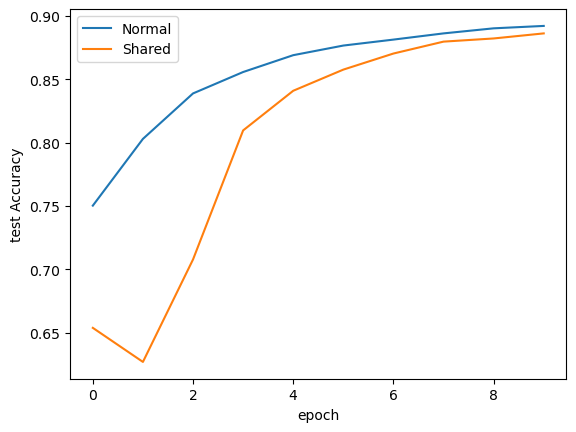

In [13]:
sns.lineplot(x='epoch', y='test Accuracy', data=regular_results, label='Normal')
sns.lineplot(x='epoch', y='test Accuracy', data=shared_results, label='Shared')

In [14]:
h_2 = nn.Linear(n, n)
model_shared = nn.Sequential(
  nn.Flatten(),
  nn.Linear(D, n),
  nn.Tanh(),
  h_2, #First use
  nn.Tanh(),
  h_2, #Second use, now sharing the weights
  nn.Tanh(),
  h_2, #Third use, now sharing the weights
  nn.Tanh(),
  nn.Linear(n, classes),
)

In [15]:
third_results = train_simple_network(model_shared, loss_func, mnist_train_loader, test_loader=mnist_test_loader, score_funcs={'Accuracy': accuracy_score}, device=device, epochs=10)

Training:  98%|███████████████████████████▍| 1836/1875 [00:02<00:00, 750.18it/s]
                                                                                
Training:  99%|███████████████████████████▋| 1855/1875 [00:02<00:00, 581.66it/s]
                                                                                
Training:  99%|███████████████████████████▊| 1859/1875 [00:02<00:00, 660.98it/s]
                                                                                
Training: 100%|███████████████████████████▉| 1867/1875 [00:02<00:00, 733.73it/s]
                                                                                
Training:  98%|███████████████████████████▎| 1829/1875 [00:02<00:00, 736.47it/s]
                                                                                
Training:  97%|███████████████████████████ | 1814/1875 [00:02<00:00, 601.94it/s]
                                                                                
Training:  96%|█████████████

<Axes: xlabel='epoch', ylabel='test Accuracy'>

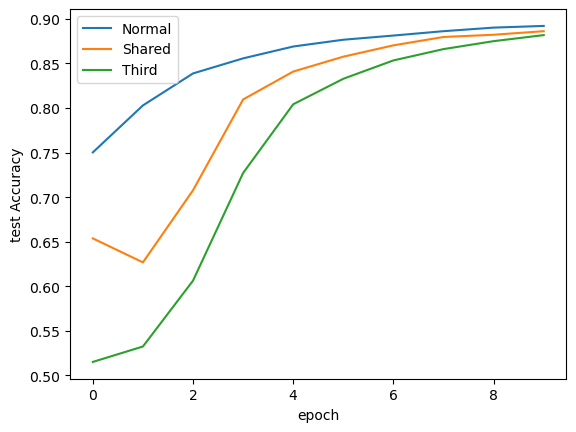

In [16]:
sns.lineplot(x='epoch', y='test Accuracy', data=regular_results, label='Normal')
sns.lineplot(x='epoch', y='test Accuracy', data=shared_results, label='Shared')
sns.lineplot(x='epoch', y='test Accuracy', data=third_results, label='Third')

Can you add another h_2 in your network and see if this additional shared weight making any more difference. Please add this third experiment to your line plot (train loss).
